# Sheet 7 — Markov Chain Monte Carlo: Solutions

# 7.1 A solvable model of a correlated chain

Real MCMC output is correlated, and the quantities of Section 6.6 are usually estimated numerically. There is, however, one model of a chain for which *everything* can be done by hand: the stationary first-order autoregressive (AR(1)) process. It is the simplest stochastic process that is Markovian, reversible, and produces exponentially correlated samples. Consider the chain

$$x_t = \phi\,x_{t-1} + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0,\sigma_\varepsilon^2)\ \text{i.i.d.},\qquad |\phi| < 1,$$

with transition kernel $T(x'\mid x) = \mathcal{N}(x';\,\phi x,\,\sigma_\varepsilon^2)$.

a. Show that the chain has a Gaussian stationary distribution $\pi(x) = \mathcal{N}(x;0,\sigma_x^2)$ and determine $\sigma_x^2$ in terms of $\sigma_\varepsilon^2$ and $\phi$. Why does the condition $|\phi|<1$ appear?

b. Verify that the chain satisfies detailed balance, $\pi(x)\,T(x'\mid x) = \pi(x')\,T(x\mid x')$, by showing that the joint density of $(x_t,x_{t+1})$ in equilibrium is symmetric under $x \leftrightarrow x'$.

c. Using the recursion and the independence of $\varepsilon_t$ from the past, show that the autocovariance at lag $\tau\ge 0$ obeys 

$$ \langle X_t X_{t-\tau}\rangle = \gamma(\tau)=\phi\,\gamma(\tau-1), $$

and conclude that the autocorrelation function of Eq. (6.32) is

$$\rho(\tau) = \phi^{|\tau|}.$$

Interpret $\phi$: what does $\phi\to 1$ correspond to for a random-walk Metropolis chain with a very small step size?

d. Evaluate the sum in Eq. (6.33) in closed form and show

   $$\tau_\mathrm{int} = 1 + 2\sum_{\tau=1}^{\infty}\phi^\tau = \frac{1+\phi}{1-\phi}.$$

e. For a chain of length $N$, give $N_\mathrm{eff}=N/\tau_\mathrm{int}$ and the variance of the mean estimator from Eq. (6.34). Then:
   1. Evaluate $\tau_\mathrm{int}$ and $N_\mathrm{eff}$ for $\phi = 0.95,\,0.98,\,0.99$ with $N = 10^6$.
   2. What value of $\phi$ reproduces the $\tau_\mathrm{int}=10^3$ quoted in Section 6.6? Comment on how close to $1$ the autocorrelation coefficient must be to lose three orders of magnitude of independent samples.


---

### Solution

**a.** Taking expectations of the recursion in stationarity: $\mu = \phi\mu$, so $\mu = 0$ for $|\phi|<1$. Taking the variance with $\varepsilon_t \perp X_{t-1}$:

$$\operatorname{Var}(X_t) = \phi^2\operatorname{Var}(X_{t-1}) + \sigma_\varepsilon^2 \xrightarrow{\text{stationarity}} \sigma_X^2 = \phi^2\sigma_X^2 + \sigma_\varepsilon^2 \implies \sigma_X^2 = \frac{\sigma_\varepsilon^2}{1-\phi^2}.$$

Because $X_t = \phi X_{t-1} + \varepsilon_t$ is a linear map of $(X_{t-1}, \varepsilon_t)$, both Gaussian, $X_t$ is Gaussian whenever $X_{t-1}$ is; by induction the stationary distribution is $\mathcal{N}(0,\sigma_X^2)$. The condition $|\phi|<1$ is needed so that $1-\phi^2 > 0$; for $|\phi|\geq 1$ the variance $\sigma_X^2$ is negative or infinite and no stationary distribution exists — the chain is explosive.

**b.** Write $\pi(x)\,T(x'\mid x)$ explicitly and expand the combined exponent:

$$-\frac{x^2}{2\sigma_X^2} - \frac{(x'-\phi x)^2}{2\sigma_\varepsilon^2} = -\frac{(1-\phi^2)x^2 + x'^2 - 2\phi xx' + \phi^2 x^2}{2\sigma_\varepsilon^2} = -\frac{x^2 + x'^2 - 2\phi xx'}{2\sigma_\varepsilon^2},$$

where we used $\sigma_\varepsilon^2/\sigma_X^2 = 1-\phi^2$ in the first step and cancelled the $\phi^2 x^2$ terms in the second. The result is manifestly symmetric under $x\leftrightarrow x'$. The normalising prefactor $(\sigma_X\sigma_\varepsilon)^{-1}$ is the same on both sides, so $\pi(x)\,T(x'\mid x) = \pi(x')\,T(x\mid x')$ and $\pi$ is stationary.

**c.** Multiply the recursion by $X_{t-\tau}$ ($\tau\ge1$) and take expectations:

$$\gamma(\tau) = \mathbb{E}[X_t X_{t-\tau}] = \phi\,\underbrace{\mathbb{E}[X_{t-1}X_{t-\tau}]}_{\gamma(\tau-1)} + \underbrace{\mathbb{E}[\varepsilon_t X_{t-\tau}]}_{=\,0} = \phi\,\gamma(\tau-1).$$

The cross-term vanishes because $\varepsilon_t$ is i.i.d. and hence independent of the entire past $\sigma(X_s,\,s\le t-1)$. Iterating the one-step relation $\tau$ times:

$$\gamma(\tau) = \phi\,\gamma(\tau-1) = \phi^2\,\gamma(\tau-2) = \cdots = \phi^\tau\,\gamma(0) = \phi^\tau\,\sigma_X^2.$$

Dividing by $\gamma(0)=\sigma_X^2$ gives $\rho(\tau)=\phi^\tau$ for $\tau\ge0$; stationarity (time-reversal symmetry) extends this to $\rho(\tau)=\phi^{|\tau|}$ for all $\tau\in\mathbb{Z}$.

For RWM with proposal scale $\delta\ll\sigma$ (posterior width), the acceptance rate approaches 1 and successive states differ by only $\sim\delta$. A continuous-limit analysis gives $\phi\approx 1-\delta^2/\sigma^2\to 1^-$, reproducing exactly the strongly correlated AR(1) regime: the chain performs a slow random walk across the target.

**d.** For $|\phi|<1$ the geometric series sums to $\sum_{\tau=1}^{\infty}\phi^\tau = \phi/(1-\phi)$, so

$$\tau_\mathrm{int} = 1 + 2\sum_{\tau=1}^{\infty}\phi^\tau = 1 + \frac{2\phi}{1-\phi} = \frac{(1-\phi)+2\phi}{1-\phi} = \frac{1+\phi}{1-\phi}.$$

**e.** From Eq. (6.34), $\operatorname{Var}(\hat{I}_N) = \sigma_X^2\,\tau_\mathrm{int}/N$ and $N_\mathrm{eff} = N/\tau_\mathrm{int} = N(1-\phi)/(1+\phi)$.

   1. Numerical values for $N=10^6$:

      | $\phi$ | $\tau_\mathrm{int}=\tfrac{1+\phi}{1-\phi}$ | $N_\mathrm{eff}=10^6/\tau_\mathrm{int}$ |
      |:---:|:---:|:---:|
      | 0.95 | $1.95/0.05 = 39$ | $\approx 2.6\times10^4$ |
      | 0.98 | $1.98/0.02 = 99$ | $\approx 1.0\times10^4$ |
      | 0.99 | $1.99/0.01 = 199$ | $\approx 5.0\times10^3$ |

   2. Setting $\tau_\mathrm{int}=10^3$:
      $$\frac{1+\phi}{1-\phi}=10^3 \implies 1+\phi = 1000(1-\phi) \implies 1001\,\phi = 999 \implies \phi = \frac{999}{1001}\approx 0.998.$$
      An autocorrelation coefficient that differs from unity by only $\Delta\phi = 1-\phi \approx 2\times10^{-3}$ already discards $99.9\%$ of the nominal chain length. This is why $N_\mathrm{eff}$, not $N$, must always be reported.


# 7.2 When Metropolis–Hastings fails: multimodal posteriors

Standard MH with a local proposal can fail catastrophically when the target has well-separated modes: the chain gets trapped and never crosses the low-probability valley between them, making every posterior estimate biased.

Consider the symmetric bimodal target distribution
$$
\pi(\theta) = \frac{1}{2}\mathcal{N}(\theta;\,-5,\,1) + \frac{1}{2}\mathcal{N}(\theta;\,+5,\,1).
$$

a. Implement a standard MH chain with a Gaussian proposal with width $\delta=0.5$ for $10^5$ steps starting from $\theta_0=-20$. Plot the trace and a histogram overlaid with the true density. What do you see?

b. Run 4 independent chains from $\theta_0\in\{-7,-3,3,7\}$ and compute the Gelman–Rubin statistic $\hat{R}$ as a function of chain length. Show that $\hat{R}\gg 1$ even after $10^5$ steps. In which situation could all chains give $\hat{R}\approx 1$ yet the sampling still be incorrect?

---

### Solution

**a.** With $\delta=0.5$ the proposal jumps by at most $\sim1$–$2$ units at a time, while the two modes are separated by 10 units. The probability of a direct crossing is $\propto e^{-25}$, so it never occurs on any reasonable run. The chain burns in quickly to the mode nearest $\theta_0=-20$ (i.e. $\mu=-5$) and then stays there permanently. This manifests in two complementary ways:

- *Trace plot*: the chain fluctuates around $\theta\approx-5$ for all $10^5$ steps; the value $\theta\approx+5$ is never visited.
- *Histogram*: the empirical distribution matches $\mathcal{N}(\theta;-5,1)$ well but has zero probability mass near $+5$, completely missing the right mode that contributes half the true probability.

The high acceptance rate ($\approx 84\%$, well above the 23.4% guideline) signals that the proposal is too small: the chain accepts nearly every local step precisely *because* it never tries to go anywhere far.

**b.** Starting from $\{-7,-3,+3,+7\}$, chains initialised at $-7$ and $-3$ both converge to the left mode ($\theta\approx-5$), while those from $+3$ and $+7$ converge to the right mode ($\theta\approx+5$). Within each group the chains look converged (within-chain variance $W\approx1$), but the group means differ by $\approx10$. The Gelman–Rubin statistic measures the ratio of the estimated marginal variance to the within-chain variance:

$$\hat{V} = \frac{n-1}{n}W + \frac{B}{n},\qquad \hat{R}=\sqrt{\frac{\hat{V}}{W}},$$

where $B\propto(\bar\theta_{\rm left}-\bar\theta_{\rm right})^2\approx 25 \gg W\approx 1$. So $\hat{V}\gg W$ and $\hat{R}\gg1$ for all chain lengths — correctly flagging non-convergence. The plot of $\hat{R}$ vs. chain length shows this remains large ($\hat{R}\approx\sqrt{26}\approx5$) regardless of how long the chains run.

*Pathological case where $\hat{R}\approx1$ yet sampling is incorrect*: if all four starting points are placed near the **same** mode (e.g.\ all at $\theta_0\in\{-6,-5,-4,-3\}$), every chain independently explores only the left Gaussian. The within-chain and between-chain variances are then both $\approx1$, so $\hat{R}\approx1$ — yet the right mode contributes zero samples. This is why Gelman–Rubin requires *over-dispersed* starting points that span the full parameter space; if the starting distribution is itself concentrated in one region, $\hat{R}$ cannot detect that other regions exist.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import shutil, os

# ── Style ────────────────────────────────────────────────────────────────────
fontsi  = 15
fontsi2 = 20
if shutil.which('latex') is not None:
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size':         fontsi,
    'axes.titlesize':    fontsi2,
    'axes.labelsize':    fontsi2 - 1,
    'xtick.labelsize':   fontsi,
    'ytick.labelsize':   fontsi,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
    'legend.frameon':    False,
    'figure.dpi':        130,
})
os.makedirs('sheet7_output', exist_ok=True)
C_BLUE   = '#1f4e79'
C_ORANGE = '#8c2d19'
C_GREEN  = '#2d6a4f'
C_GRAY   = '#6c757d'
C_RED    = '#c0392b'

# ── Bimodal target and MH sampler ─────────────────────────────────────────────
def gaussian_logpdf(x, mu, sigma):
    return -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((x - mu) / sigma)**2

def log_post(theta, mu1=-5, sigma1=1, mu2=5, sigma2=1):
    return np.log(
        np.exp(gaussian_logpdf(theta, mu1, sigma1))
        + np.exp(gaussian_logpdf(theta, mu2, sigma2))
    )

def mh_sampler(start, n_steps, delta, mu1=-5, sigma1=1, mu2=5, sigma2=1, seed=0):
    rng_loc = np.random.default_rng(seed)
    chain   = np.empty((n_steps, 1))
    chain[0, 0] = start
    log_p_curr  = log_post(start, mu1, sigma1, mu2, sigma2)
    n_accept = 0
    for t in range(1, n_steps):
        theta_p    = chain[t - 1] + delta * rng_loc.standard_normal(1)
        log_p_prop = log_post(theta_p, mu1, sigma1, mu2, sigma2)
        if np.log(rng_loc.uniform()) < log_p_prop - log_p_curr:
            chain[t, 0] = theta_p
            log_p_curr  = log_p_prop
            n_accept += 1
        else:
            chain[t, 0] = chain[t - 1, 0]
    return chain, n_accept / n_steps

n_steps = 100_000
delta   = 0.5
chain, acc_rate = mh_sampler(-20, n_steps=n_steps, delta=delta)
print(f"Acceptance rate (delta={delta}): {acc_rate:.3f}")


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_73825/2221897296.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chain[t, 0] = theta_p


Acceptance rate (delta=0.5): 0.844


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_73825/893869693.py:3: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  true_pdf   = np.exp(log_post(theta_grid)) / np.trapz(np.exp(log_post(theta_grid)), theta_grid)


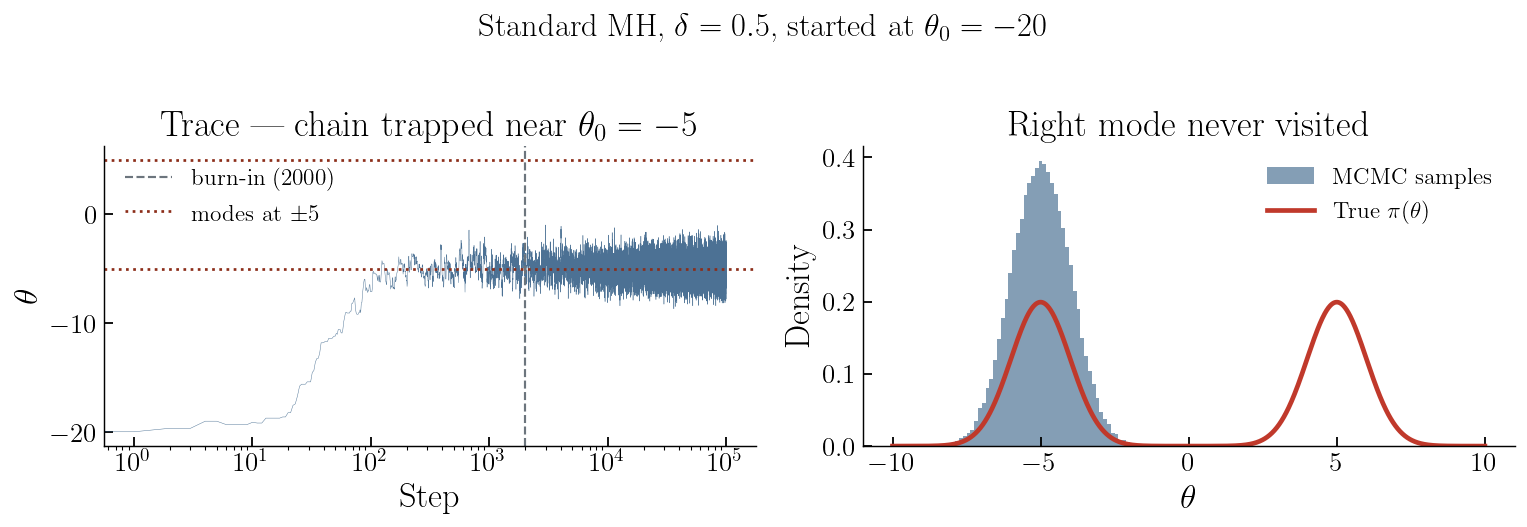

In [38]:
burn_in    = 2_000
theta_grid = np.linspace(-10, 10, 1000)
true_pdf   = np.exp(log_post(theta_grid)) / np.trapz(np.exp(log_post(theta_grid)), theta_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Trace plot ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.semilogx(chain[:, 0], lw=0.25, color=C_BLUE, alpha=0.8, rasterized=True)
ax.axvline(burn_in, color=C_GRAY, ls='--', lw=1.2, label=f'burn-in ({burn_in})')
ax.axhline(-5, color=C_ORANGE, ls=':', lw=1.5, label=r'modes at $\pm 5$')
ax.axhline( 5, color=C_ORANGE, ls=':', lw=1.5)
ax.set_xlabel('Step')
ax.set_ylabel(r'$\theta$')
ax.set_title(r'Trace — chain trapped near $\theta_0 = -5$')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

# ── Histogram + true density ─────────────────────────────────────────────────
ax = axes[1]
ax.hist(chain[burn_in:, 0], bins=60, density=True,
        color=C_BLUE, alpha=0.55, label='MCMC samples')
ax.plot(theta_grid, true_pdf, lw=2.6, color=C_RED, label=r'True $\pi(\theta)$')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel('Density')
ax.set_title('Right mode never visited')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)
#ax.set_yscale('log')

plt.suptitle(r'Standard MH, $\delta=0.5$, started at $\theta_0=-20$', y=1.02)
plt.tight_layout()
plt.savefig('sheet7_output/fig_7b_mh_bimodal.pdf', bbox_inches='tight')
plt.show()


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_73825/2221897296.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  chain[t, 0] = theta_p


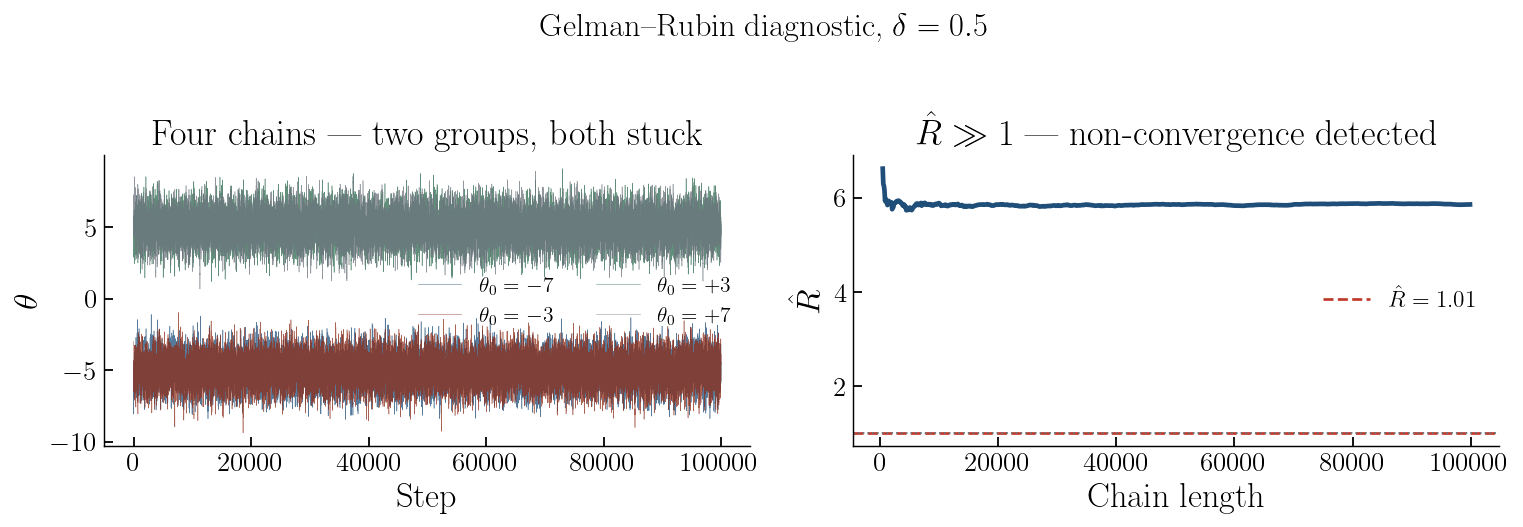

Final R̂ after 100000 steps: 5.86


In [41]:
def gelman_rubin_vs_length(chains, burn_frac=0.5):
    n_total = chains[0].shape[0]
    M       = len(chains)
    lengths = np.arange(400, n_total, 100)
    R_hat   = []
    for n in lengths:
        bi      = int(n * burn_frac)
        slices  = [ch[bi:n] for ch in chains]
        n_s     = n - bi
        means   = np.array([s.mean() for s in slices])
        vars_   = np.array([s.var(ddof=1) for s in slices])
        grand   = means.mean()
        B       = n_s / (M - 1) * np.sum((means - grand)**2)
        W       = vars_.mean()
        var_hat = (n_s - 1) / n_s * W + B / n_s
        R_hat.append(np.sqrt(var_hat / W))
    return lengths, np.array(R_hat)

# ── Four over-dispersed chains ────────────────────────────────────────────────
starts   = [-7.0, -3.0, 3.0, 7.0]
chain_colors = [C_BLUE, C_ORANGE, C_GREEN, C_GRAY]
chains_b = [mh_sampler(s, n_steps=n_steps, delta=delta, seed=i)[0][:, 0]
            for i, s in enumerate(starts)]

lengths_b, R_hat_b = gelman_rubin_vs_length(chains_b, burn_frac=0.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Trace overlay ─────────────────────────────────────────────────────────────
ax = axes[0]
for ch, s, col in zip(chains_b, starts, chain_colors):
    ax.plot(ch, lw=0.3, alpha=0.75, color=col, rasterized=True,
            label=rf'$\theta_0={s:+.0f}$')
ax.set_xlabel('Step')
ax.set_ylabel(r'$\theta$')
ax.set_title('Four chains — two groups, both stuck')
ax.legend(fontsize=fontsi - 3, ncol=2)
ax.tick_params(direction='in', length=5, width=1.0)

# ── R̂ vs chain length ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(lengths_b, R_hat_b, color=C_BLUE, lw=2.6)
ax.axhline(1.01, color=C_RED,  ls='--', lw=1.5, label=r'$\hat{R}=1.01$')
ax.axhline(1.00, color=C_GRAY, ls=':',  lw=1.0)
ax.set_xlabel('Chain length')
ax.set_ylabel(r'$\hat{R}$')
ax.set_title(r'$\hat{R}\gg 1$ — non-convergence detected')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

plt.suptitle(r'Gelman–Rubin diagnostic, $\delta=0.5$', y=1.02)
plt.tight_layout()
plt.savefig('sheet7_output/fig_7b_gelman_rubin.pdf', bbox_inches='tight')
plt.show()

print(f"Final R̂ after {n_steps} steps: {R_hat_b[-1]:.2f}")


Bimodal MH chain (δ=0.5, single mode trapped)
  N post burn-in :    98000
  τ_int          :     21.0
  N_eff          :     4657


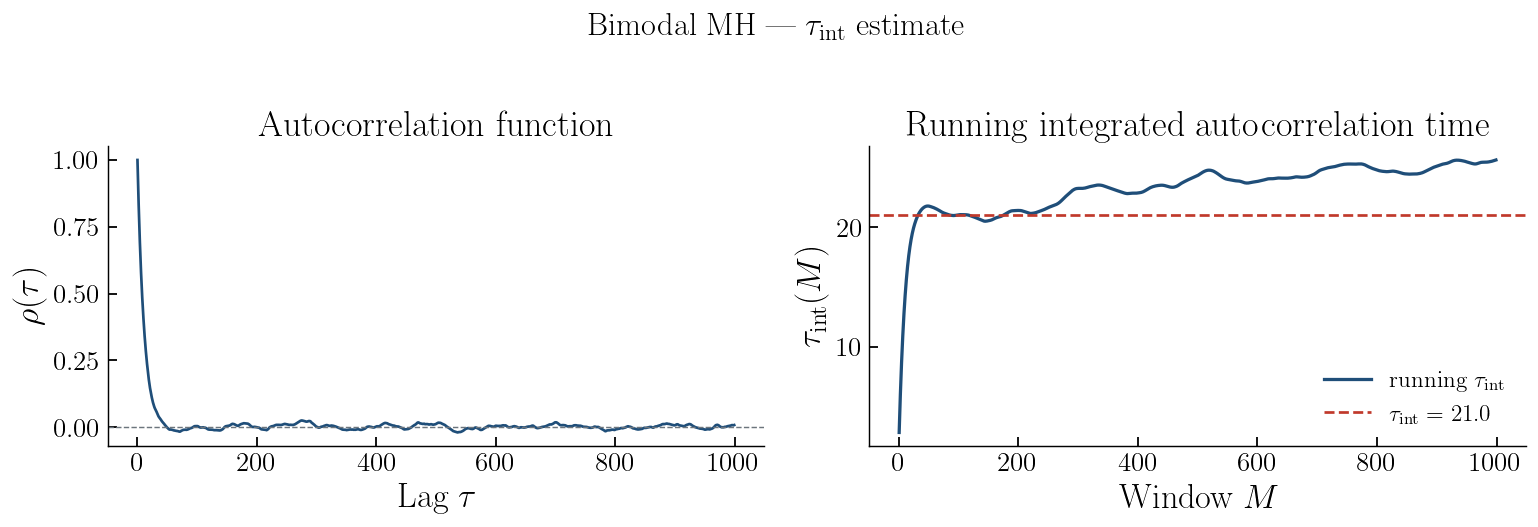

In [40]:
# ── Integrated autocorrelation time ──────────────────────────────────────────
#
# The naive truncated sum  τ = 1 + 2Σρ(τ)  accumulates noise from the tail;
# instead we stop at the first window M where M ≥ c·τ_int(M).
# c = 5 is the standard choice (Goodman & Weare 2010, Foreman-Mackey 2017).

def acf(x):
    """Normalised autocorrelation via FFT (Wiener–Khinchin theorem)."""
    n  = len(x)
    xc = x - x.mean()
    f  = np.fft.rfft(xc, n=2 * n)
    ac = np.fft.irfft(f * np.conj(f))[:n].real
    return ac / ac[0]

def integrated_autocorr_time(chain, c=5):
    """
    Returns (tau_int, N_eff) for a 1-D chain using the automatic windowing
    estimator.  Works for any post-burn-in 1-D array.

    Parameters
    ----------
    chain : 1-D array  – post-burn-in samples
    c     : float      – window factor (default 5)
    """
    n     = len(chain)
    rho   = acf(chain)
    # running sum: tau_int at window M = 1 + 2*sum_{k=1}^{M} rho(k)
    tau   = 1.0 + 2.0 * np.cumsum(rho[1:])
    lags  = np.arange(1, len(tau) + 1)
    # stop at first M ≥ c * τ_int(M)  (automatic window)
    mask  = lags >= c * tau
    tau_int = float(tau[mask][0]) if mask.any() else float(tau[-1])
    return tau_int, n / tau_int

# ── Demo on the single bimodal MH chain ──────────────────────────────────────
post_bi = chain[burn_in:, 0]
tau_int_bi, n_eff_bi = integrated_autocorr_time(post_bi)
print(f"Bimodal MH chain (δ={delta}, single mode trapped)")
print(f"  N post burn-in : {len(post_bi):>8d}")
print(f"  τ_int          : {tau_int_bi:>8.1f}")
print(f"  N_eff          : {n_eff_bi:>8.0f}")

# plot the ACF and the running τ_int
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
max_lag = min(1000, len(post_bi) // 4)
lags_plot = np.arange(max_lag)
rho_bi    = acf(post_bi)

ax = axes[0]
ax.plot(lags_plot, rho_bi[:max_lag], lw=1.5, color=C_BLUE)
ax.axhline(0, color=C_GRAY, lw=0.8, ls='--')
ax.set_xlabel(r'Lag $\tau$')
ax.set_ylabel(r'$\rho(\tau)$')
ax.set_title('Autocorrelation function')
ax.tick_params(direction='in', length=5, width=1.0)

ax = axes[1]
tau_running = 1.0 + 2.0 * np.cumsum(rho_bi[1:max_lag])
ax.plot(np.arange(1, max_lag), tau_running, lw=1.8, color=C_BLUE, label=r'running $\tau_{\rm int}$')
ax.axhline(tau_int_bi, color=C_RED, ls='--', lw=1.5,
           label=rf'$\tau_{{\rm int}}={tau_int_bi:.1f}$')
ax.set_xlabel(r'Window $M$')
ax.set_ylabel(r'$\tau_{\rm int}(M)$')
ax.set_title('Running integrated autocorrelation time')
ax.legend(fontsize=fontsi - 2)
ax.tick_params(direction='in', length=5, width=1.0)

plt.suptitle(r'Bimodal MH — $\tau_{\rm int}$ estimate', y=1.02)
plt.tight_layout()
plt.savefig('sheet7_output/fig_7_tau_int.pdf', bbox_inches='tight')
plt.show()
